# Credit Card Fraud Detection using Machine Learning

**Lakshay** &nbsp;|&nbsp; Roll No: AP24110010677 &nbsp;|&nbsp; B.Tech CSE
&nbsp;|&nbsp; SRM University - AP
Supervisor: Mr. Ajay Dilip Kumar Marapatla

> Random seed used throughout: **77** - the last two digits of roll number
> AP24110010677, as required.

---

# Notebook 08 - Ensemble Learning

**Syllabus coverage - UNIT V**

| Topic from the unitization plan | Where it appears below |
|---|---|
| Ensembles: Introduction | Section 1 |
| Bagging | Section 2 |
| Random Forest | Section 3 |
| Boosting | Section 4 |
| Fixed rule fusion techniques | Section 5 |
| Trained rule fusion techniques | Section 6 |

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import utils
from utils import SEED

print(utils.HEADER)
df = utils.load_data()
X_train, X_test, y_train, y_test = utils.make_split(df)


Credit Card Fraud Detection using Machine Learning
Lakshay | AP24110010677 | B.Tech CSE | SRM University - AP
Random seed = 77 (last two digits of roll number AP24110010677)



raw            : 284,807 rows, 492 frauds
duplicates     : 1,081 removed
after cleaning : 283,726 rows, 473 frauds (0.1667%)
train : 198,608 rows, 331 frauds
test  : 85,118 rows, 142 frauds


## 1. Introduction to ensembles

An ensemble combines several *base learners* into one predictor that is usually
better than any of them alone. It works when the base learners make **different
mistakes**: if their errors are uncorrelated, combining them cancels part of the
error out.

The classification error of a model decomposes into

$$ \text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible noise} $$

and the two main ensemble families attack different terms:

| Family | Base learners | Trained | Attacks | Example |
|---|---|---|---|---|
| **Bagging** | Strong, low bias, high variance (deep trees) | In parallel, independently | Variance | Random Forest |
| **Boosting** | Weak, high bias, low variance (shallow trees) | Sequentially, each fixing the last | Bias | AdaBoost, XGBoost |

Beyond these, the outputs of several *different* model types can be combined by
**rule fusion**, which Unit V splits into *fixed* rules (Section 5) and
*trained* rules (Section 6).

## 2. Bagging - bootstrap aggregating

Bagging builds each base learner on a different **bootstrap sample** of the
training data: a sample of the same size drawn *with replacement*. Roughly 63%
of the original rows appear in any given bootstrap sample; the remaining ~37%
are the **out-of-bag** examples and can be used as a free validation set.

Predictions are combined by majority vote. Because each tree sees a slightly
different dataset, the trees differ, and averaging them reduces variance without
increasing bias.

In [2]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, average_precision_score, recall_score
import time

# A single unpruned tree - high variance, the ideal base learner for bagging
single = DecisionTreeClassifier(criterion="entropy", class_weight="balanced",
                                random_state=SEED).fit(X_train, y_train)
p_single = single.predict(X_test)
pr_single = single.predict_proba(X_test)[:, 1]
print(f"Single unpruned tree : F1 = {f1_score(y_test, p_single):.4f}   "
      f"PR-AUC = {average_precision_score(y_test, pr_single):.4f}")

Single unpruned tree : F1 = 0.7153   PR-AUC = 0.5129


In [3]:
t0 = time.time()
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(criterion="entropy", class_weight="balanced",
                                     random_state=SEED),
    n_estimators=20, max_samples=1.0, bootstrap=True,
    oob_score=True, random_state=SEED, n_jobs=-1)
bag.fit(X_train, y_train)
p_bag  = bag.predict(X_test)
pr_bag = bag.predict_proba(X_test)[:, 1]
print(f"Bagging (20 trees)   : F1 = {f1_score(y_test, p_bag):.4f}   "
      f"PR-AUC = {average_precision_score(y_test, pr_bag):.4f}   ({time.time()-t0:.1f}s)")
print(f"out-of-bag score     : {bag.oob_score_:.6f}")
print(f"\nVariance reduction from bagging is visible in the PR-AUC improvement")
print(f"over the single tree, with no change to the base learner itself.")

Bagging (20 trees)   : F1 = 0.8306   PR-AUC = 0.8168   (36.6s)
out-of-bag score     : 0.999491

Variance reduction from bagging is visible in the PR-AUC improvement
over the single tree, with no change to the base learner itself.


## 3. Random Forest

Random Forest extends bagging with a second source of randomness. At **every
split**, instead of considering all 30 attributes, the tree considers only a
random subset (commonly $\sqrt{d}$ of them).

The reason is subtle but important. With plain bagging, if one attribute is very
strong, nearly every tree will split on it at the root, so the trees end up
highly correlated and averaging them helps less. Restricting the candidate
attributes at each split **decorrelates** the trees, which makes the averaging
far more effective.

In [4]:
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=200,
    max_features="sqrt",         # the decorrelating restriction
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    oob_score=True,
    random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
fit_rf = time.time() - t0

y_pred_rf  = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]
print(f"training time : {fit_rf:.1f} seconds for {rf.n_estimators} trees")
print(f"max_features  : sqrt(30) = {int(np.sqrt(30))} attributes considered per split")
print(f"oob score     : {rf.oob_score_:.6f}")

res_rf = utils.evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf,
                        unit="Unit V - Ensembles: bagging, Random Forest")
res_rf["ensemble_type"] = "bagging"
utils.save_result(res_rf, y_proba_rf)

training time : 80.9 seconds for 200 trees
max_features  : sqrt(30) = 5 attributes considered per split
oob score     : 0.999481

===== Random Forest =====
syllabus  : Unit V - Ensembles: bagging, Random Forest
accuracy  : 0.99951
precision : 0.9717
recall    : 0.7254
f1-score  : 0.8306
PR-AUC    : 0.8659
ROC-AUC   : 0.9692
confusion : TN=84,973  FP=3  FN=39  TP=103

              precision    recall  f1-score   support

  Legitimate     0.9995    1.0000    0.9998     84976
       Fraud     0.9717    0.7254    0.8306       142

    accuracy                         0.9995     85118
   macro avg     0.9856    0.8627    0.9152     85118
weighted avg     0.9995    0.9995    0.9995     85118

saved result -> Results/tables/random_forest.json


In [5]:
# Does adding trees keep helping?
rows = []
for n in [1, 5, 10, 25, 50, 100]:
    r = RandomForestClassifier(n_estimators=n, max_features="sqrt", min_samples_leaf=2,
                               class_weight="balanced_subsample",
                               random_state=SEED, n_jobs=-1).fit(X_train, y_train)
    ap = average_precision_score(y_test, r.predict_proba(X_test)[:, 1])
    rows.append({"n_trees": n, "pr_auc": ap})
    print(f"  {n:>3} trees : PR-AUC = {ap:.4f}")
nt = pd.DataFrame(rows)

    1 trees : PR-AUC = 0.5253


    5 trees : PR-AUC = 0.8052


   10 trees : PR-AUC = 0.8185


   25 trees : PR-AUC = 0.8406


   50 trees : PR-AUC = 0.8498


  100 trees : PR-AUC = 0.8615


saved figure -> Results/figures/08_rf_n_estimators.png


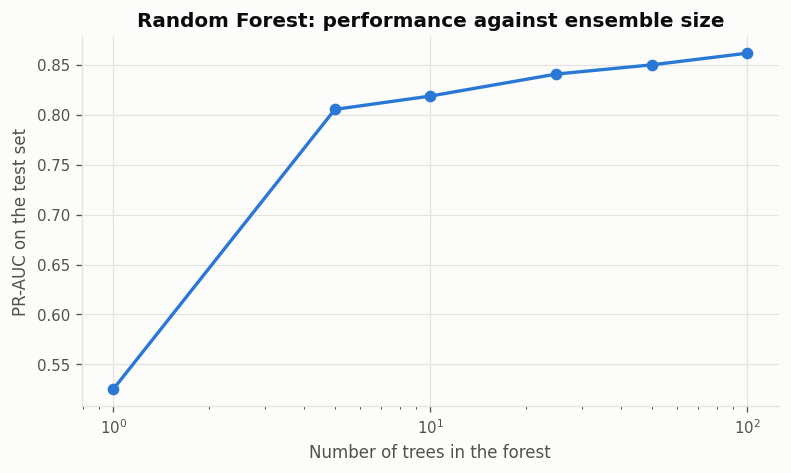

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(nt["n_trees"], nt["pr_auc"], marker="o", color=utils.BLUE)
ax.set_xscale("log")
ax.set_xlabel("Number of trees in the forest")
ax.set_ylabel("PR-AUC on the test set")
ax.set_title("Random Forest: performance against ensemble size")
utils.despine(ax)
utils.save_fig(fig, "08_rf_n_estimators.png")
plt.show()

Performance climbs steeply at first and then plateaus. Adding trees to a Random
Forest never causes overfitting - it only reduces variance - but past a point
the returns vanish and the cost keeps rising.

saved figure -> Results/figures/08_rf_importance.png


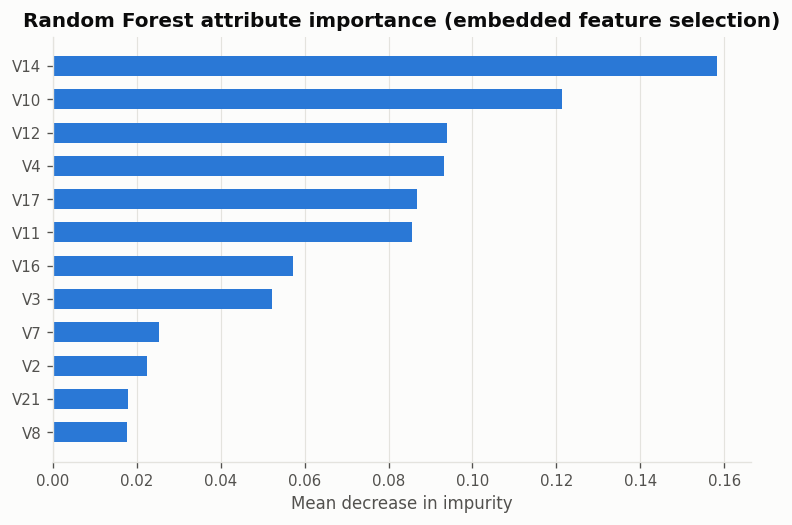

V14    0.15837
V10    0.12127
V12    0.09393
V4     0.09330
V17    0.08677
V11    0.08562
V16    0.05731
V3     0.05230
V7     0.02529
V2     0.02231
V21    0.01796
V8     0.01761
dtype: float64

In [7]:
imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
t = imp.head(12)
ax.barh(t.index[::-1], t.values[::-1], color=utils.BLUE, height=0.6)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Random Forest attribute importance (embedded feature selection)")
ax.grid(axis="y", visible=False); utils.despine(ax)
utils.save_fig(fig, "08_rf_importance.png")
plt.show()
imp.head(12).round(5)

## 4. Boosting

Boosting trains base learners **sequentially**. Each new learner concentrates on
the examples the ensemble has so far got wrong.

**AdaBoost** does this by reweighting: after each round, misclassified examples
get larger weights, so the next learner pays more attention to them. The final
prediction is a weighted vote, with each learner's weight $\alpha_t$ determined
by its accuracy.

**Gradient boosting** (and XGBoost) generalises the idea: each new tree is fitted
to the *residual errors* of the ensemble so far, so the ensemble descends the
gradient of the loss function in function space.

Because base learners are deliberately weak (shallow trees), boosting reduces
**bias**. The price is that it can overfit if run too long, and it cannot be
parallelised the way bagging can.

In [8]:
t0 = time.time()
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3, random_state=SEED),
    n_estimators=60, learning_rate=0.5, random_state=SEED)
ada.fit(X_train, y_train)
p_ada  = ada.predict(X_test)
pr_ada = ada.predict_proba(X_test)[:, 1]
print(f"AdaBoost (60 stumps of depth 3) : F1 = {f1_score(y_test, p_ada):.4f}   "
      f"PR-AUC = {average_precision_score(y_test, pr_ada):.4f}   ({time.time()-t0:.1f}s)")

res_ada = utils.evaluate("AdaBoost", y_test, p_ada, pr_ada,
                         unit="Unit V - Ensembles: boosting", show=False)
res_ada["ensemble_type"] = "boosting"
utils.save_result(res_ada, pr_ada)
print(f"recall {res_ada['recall']:.4f}  precision {res_ada['precision']:.4f}")

AdaBoost (60 stumps of depth 3) : F1 = 0.8340   PR-AUC = 0.8289   (143.8s)
saved result -> Results/tables/adaboost.json
recall 0.7606  precision 0.9231


In [9]:
from xgboost import XGBClassifier

scale_pos = float((np.asarray(y_train) == 0).sum() / (np.asarray(y_train) == 1).sum())
print(f"scale_pos_weight = {scale_pos:.1f}  (ratio of legitimate to fraud in training)")

t0 = time.time()
xgb = XGBClassifier(
    n_estimators=400, learning_rate=0.1, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric="aucpr", tree_method="hist",
    random_state=SEED, n_jobs=-1)
xgb.fit(X_train, y_train)
fit_xgb = time.time() - t0

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
print(f"training time : {fit_xgb:.1f} seconds")

res_xgb = utils.evaluate("XGBoost", y_test, y_pred_xgb, y_proba_xgb,
                         unit="Unit V - Ensembles: boosting")
res_xgb["ensemble_type"] = "boosting"
utils.save_result(res_xgb, y_proba_xgb)

scale_pos_weight = 599.0  (ratio of legitimate to fraud in training)


training time : 5.0 seconds

===== XGBoost =====
syllabus  : Unit V - Ensembles: boosting
accuracy  : 0.99962
precision : 0.9508
recall    : 0.8169
f1-score  : 0.8788
PR-AUC    : 0.8774
ROC-AUC   : 0.9825
confusion : TN=84,970  FP=6  FN=26  TP=116

              precision    recall  f1-score   support

  Legitimate     0.9997    0.9999    0.9998     84976
       Fraud     0.9508    0.8169    0.8788       142

    accuracy                         0.9996     85118
   macro avg     0.9753    0.9084    0.9393     85118
weighted avg     0.9996    0.9996    0.9996     85118

saved result -> Results/tables/xgboost.json


saved figure -> Results/figures/08_confusion_rf.png


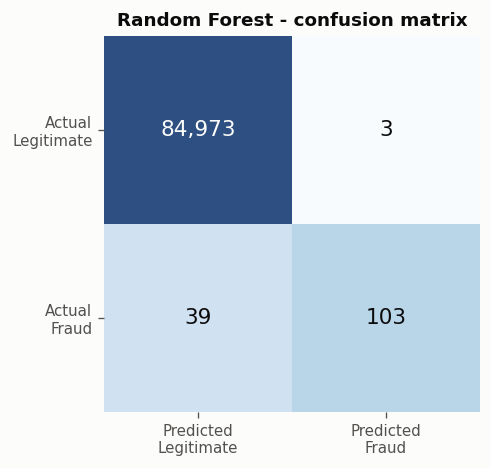

saved figure -> Results/figures/08_confusion_xgb.png


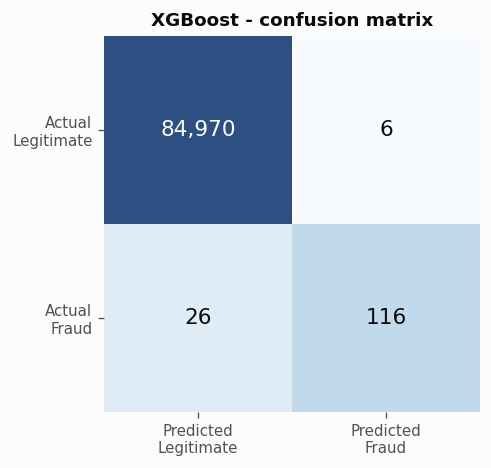

In [10]:
utils.plot_confusion(y_test, y_pred_rf,  "Random Forest - confusion matrix",
                     "08_confusion_rf.png"); plt.show()
utils.plot_confusion(y_test, y_pred_xgb, "XGBoost - confusion matrix",
                     "08_confusion_xgb.png"); plt.show()

saved figure -> Results/figures/08_ensemble_pr_curves.png


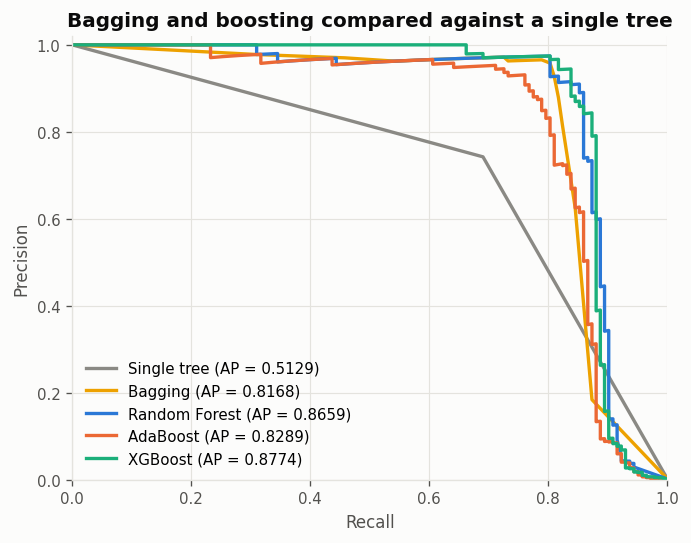

In [11]:
from sklearn.metrics import precision_recall_curve
fig, ax = plt.subplots(figsize=(6.4, 4.8))
for name, pr_, c in [("Single tree", pr_single, utils.MUTED),
                     ("Bagging", pr_bag, utils.YELLOW),
                     ("Random Forest", y_proba_rf, utils.BLUE),
                     ("AdaBoost", pr_ada, utils.ORANGE),
                     ("XGBoost", y_proba_xgb, utils.GREEN)]:
    p_, r_, _ = precision_recall_curve(y_test, pr_)
    ap = average_precision_score(y_test, pr_)
    ax.plot(r_, p_, color=c, label=f"{name} (AP = {ap:.4f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Bagging and boosting compared against a single tree")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02); ax.legend(loc="lower left")
utils.despine(ax)
utils.save_fig(fig, "08_ensemble_pr_curves.png")
plt.show()

## 5. Fixed rule fusion techniques

So far the ensembles combined many copies of the **same** kind of learner.
**Rule fusion** combines the outputs of **different** classifiers - a decision
tree, a naive Bayes, a neural network - into one decision.

A **fixed rule** uses a combination rule that is decided in advance and has no
parameters to learn from data. The common fixed rules are:

| Rule | Combination |
|---|---|
| **Majority vote** (hard voting) | The class predicted by most classifiers |
| **Mean / sum rule** (soft voting) | Average the posterior probabilities, take the argmax |
| **Product rule** | Multiply the posteriors |
| **Max rule** | Take the class with the highest posterior from any member |
| **Min rule** | Take the class whose lowest posterior across members is highest |

Nothing is trained: the rule is imposed. This makes fixed fusion simple and
robust, and it cannot overfit the fusion step, but it also treats every member
as equally trustworthy.

In [12]:
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

# Three deliberately different base learners, one from each of Units II, III, IV
base_tree = DecisionTreeClassifier(criterion="entropy", max_depth=8,
                                   min_samples_leaf=20,
                                   random_state=SEED)
base_nb   = GaussianNB()
base_mlp  = Pipeline([("s", StandardScaler()),
                      ("m", MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=30,
                                          early_stopping=True, random_state=SEED))])

print("Base learners for fusion:")
print("  Decision Tree    (Unit II)")
print("  Naive Bayes      (Unit III)")
print("  Neural Network   (Unit IV)")

Base learners for fusion:
  Decision Tree    (Unit II)
  Naive Bayes      (Unit III)
  Neural Network   (Unit IV)


In [13]:
t0 = time.time()
vote_hard = VotingClassifier(
    estimators=[("tree", base_tree), ("nb", base_nb), ("mlp", base_mlp)],
    voting="hard", n_jobs=1).fit(X_train, y_train)
p_hard = vote_hard.predict(X_test)
print(f"MAJORITY VOTE (hard) : F1 = {f1_score(y_test, p_hard):.4f}   "
      f"recall = {recall_score(y_test, p_hard):.4f}   ({time.time()-t0:.1f}s)")

res_hard = utils.evaluate("Voting (Fixed Rule Fusion)", y_test, p_hard, None,
                          unit="Unit V - Fixed rule fusion", show=False)
res_hard["fusion_rule"] = "majority vote (hard voting)"
utils.save_result(res_hard)

MAJORITY VOTE (hard) : F1 = 0.8092   recall = 0.7465   (11.2s)
saved result -> Results/tables/voting_fixed_rule_fusion.json


In [14]:
t0 = time.time()
vote_soft = VotingClassifier(
    estimators=[("tree", base_tree), ("nb", base_nb), ("mlp", base_mlp)],
    voting="soft", n_jobs=1).fit(X_train, y_train)
p_soft  = vote_soft.predict(X_test)
pr_soft = vote_soft.predict_proba(X_test)[:, 1]
print(f"MEAN RULE (soft)     : F1 = {f1_score(y_test, p_soft):.4f}   "
      f"PR-AUC = {average_precision_score(y_test, pr_soft):.4f}   ({time.time()-t0:.1f}s)")

MEAN RULE (soft)     : F1 = 0.7938   PR-AUC = 0.7953   (11.0s)


In [15]:
# Implement the product, max and min fixed rules directly from their definitions
probs = np.column_stack([
    base_tree.fit(X_train, y_train).predict_proba(X_test)[:, 1],
    base_nb.fit(X_train, y_train).predict_proba(X_test)[:, 1],
    base_mlp.fit(X_train, y_train).predict_proba(X_test)[:, 1],
])

fixed_rules = {
    "Mean (sum) rule": probs.mean(axis=1),
    "Product rule":    np.prod(probs, axis=1) ** (1/3),
    "Max rule":        probs.max(axis=1),
    "Min rule":        probs.min(axis=1),
}

print(f"{'fixed rule':<20}{'PR-AUC':>10}{'F1 @ 0.5':>11}{'recall':>10}")
print("-" * 51)
fr_rows = []
for name, pr_ in fixed_rules.items():
    pred = (pr_ > 0.5).astype(int)
    ap = average_precision_score(y_test, pr_)
    fr_rows.append({"rule": name, "pr_auc": ap, "f1": f1_score(y_test, pred),
                    "recall": recall_score(y_test, pred)})
    print(f"{name:<20}{ap:>10.4f}{f1_score(y_test, pred):>11.4f}"
          f"{recall_score(y_test, pred):>10.4f}")
fr = pd.DataFrame(fr_rows)

fixed rule              PR-AUC   F1 @ 0.5    recall
---------------------------------------------------
Mean (sum) rule         0.7953     0.7938    0.7183
Product rule            0.8030     0.7350    0.6056


Max rule                0.2747     0.2875    0.8239
Min rule                0.7669     0.6757    0.5282


saved figure -> Results/figures/08_fixed_rule_fusion.png


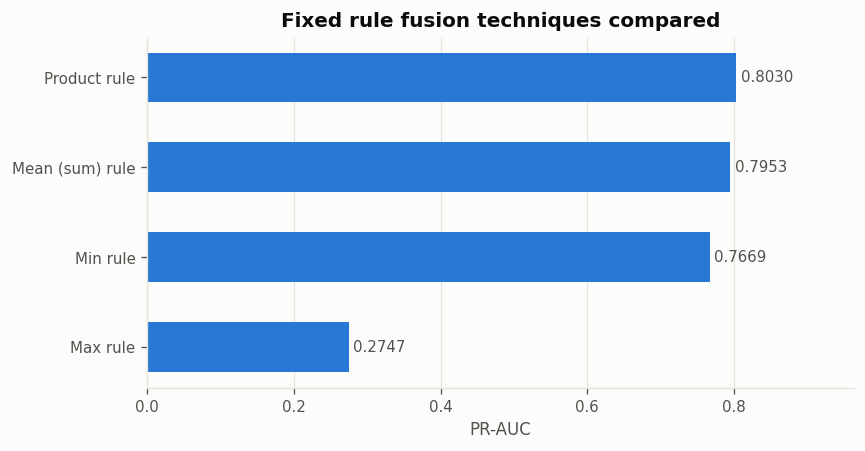

In [16]:
fig, ax = plt.subplots(figsize=(7.6, 3.8))
d = fr.sort_values("pr_auc")
ax.barh(d["rule"], d["pr_auc"], color=utils.BLUE, height=0.55)
for i, v in enumerate(d["pr_auc"]):
    ax.text(v + 0.006, i, f"{v:.4f}", va="center", fontsize=9, color=utils.INK2)
ax.set_xlim(0, d["pr_auc"].max()*1.2)
ax.set_xlabel("PR-AUC"); ax.set_title("Fixed rule fusion techniques compared")
ax.grid(axis="y", visible=False); utils.despine(ax)
utils.save_fig(fig, "08_fixed_rule_fusion.png")
plt.show()

## 6. Trained rule fusion techniques

A **trained rule** learns how to combine the base classifiers instead of fixing
the rule in advance. **Stacking** is the standard approach:

1. Split the training data into folds.
2. Train each base classifier on the training folds and predict on the held-out
   fold, producing **out-of-fold** predictions for every training row.
3. Use those predictions as the input attributes for a second-level model, the
   **meta-learner**, whose target is the true label.
4. At prediction time, the base classifiers produce their outputs and the
   meta-learner combines them.

The out-of-fold step is what makes this valid. If the base classifiers predicted
on data they had been trained on, their outputs would be unrealistically good
and the meta-learner would learn to trust them too much.

A trained rule can discover that one member is more reliable than another, or
that a particular member is reliable only in certain regions - things a fixed
rule cannot express. The cost is that the fusion step itself can overfit.

In [17]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

t0 = time.time()
stack = StackingClassifier(
    estimators=[("tree", base_tree), ("nb", base_nb), ("mlp", base_mlp)],
    final_estimator=LogisticRegression(max_iter=1000, random_state=SEED),
    cv=3,                 # out-of-fold predictions for the meta-learner
    stack_method="predict_proba",
    n_jobs=1)
stack.fit(X_train, y_train)
fit_stack = time.time() - t0

p_stack  = stack.predict(X_test)
pr_stack = stack.predict_proba(X_test)[:, 1]
print(f"training time : {fit_stack:.1f} seconds")
print(f"\nmeta-learner coefficients (how much each base model is trusted):")
meta = stack.final_estimator_
for (name, _), c in zip(stack.estimators, meta.coef_[0]):
    print(f"   {name:<6} : {c:+.4f}")
print(f"   intercept: {meta.intercept_[0]:+.4f}")

training time : 30.1 seconds

meta-learner coefficients (how much each base model is trusted):
   tree   : +5.0212
   nb     : +2.0402
   mlp    : +5.2594
   intercept: -7.6874


In [18]:
res_stack = utils.evaluate("Stacking (Trained Rule Fusion)", y_test, p_stack, pr_stack,
                           unit="Unit V - Trained rule fusion")
res_stack["fusion_rule"] = "stacking with logistic regression meta-learner"
utils.save_result(res_stack, pr_stack)


===== Stacking (Trained Rule Fusion) =====
syllabus  : Unit V - Trained rule fusion
accuracy  : 0.99933
precision : 0.9474
recall    : 0.6338
f1-score  : 0.7595
PR-AUC    : 0.8375
ROC-AUC   : 0.9840
confusion : TN=84,971  FP=5  FN=52  TP=90

              precision    recall  f1-score   support

  Legitimate     0.9994    0.9999    0.9997     84976
       Fraud     0.9474    0.6338    0.7595       142

    accuracy                         0.9993     85118
   macro avg     0.9734    0.8169    0.8796     85118
weighted avg     0.9993    0.9993    0.9993     85118

saved result -> Results/tables/stacking_trained_rule_fusion.json


In [19]:
comp = pd.DataFrame([
    {"approach": "Base: Decision Tree", "type": "single",
     "pr_auc": average_precision_score(y_test, probs[:, 0])},
    {"approach": "Base: Naive Bayes", "type": "single",
     "pr_auc": average_precision_score(y_test, probs[:, 1])},
    {"approach": "Base: Neural Network", "type": "single",
     "pr_auc": average_precision_score(y_test, probs[:, 2])},
    {"approach": "Majority vote", "type": "fixed rule fusion", "pr_auc": np.nan},
    {"approach": "Mean rule (soft vote)", "type": "fixed rule fusion",
     "pr_auc": average_precision_score(y_test, fixed_rules["Mean (sum) rule"])},
    {"approach": "Product rule", "type": "fixed rule fusion",
     "pr_auc": average_precision_score(y_test, fixed_rules["Product rule"])},
    {"approach": "Stacking", "type": "trained rule fusion",
     "pr_auc": average_precision_score(y_test, pr_stack)},
])
comp.round(4)

,approach,type,pr_auc
0,Base: Decision Tree,single,0.8046
1,Base: Naive Bayes,single,0.1798
2,Base: Neural Network,single,0.8394
3,Majority vote,fixed rule fusion,NaN
4,Mean rule (soft vote),fixed rule fusion,0.7953
5,Product rule,fixed rule fusion,0.8030
6,Stacking,trained rule fusion,0.8375


saved figure -> Results/figures/08_fusion_comparison.png


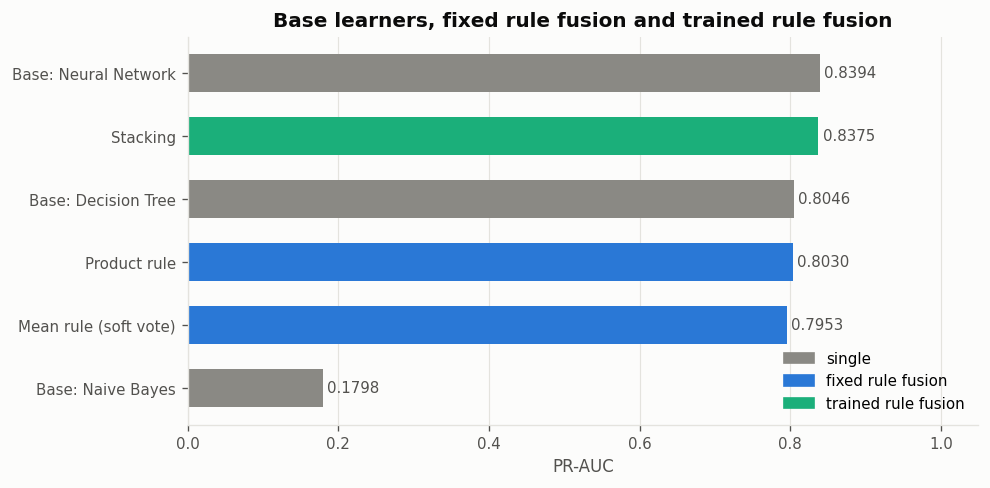

In [20]:
d = comp.dropna(subset=["pr_auc"]).sort_values("pr_auc")
cmap = {"single": utils.MUTED, "fixed rule fusion": utils.BLUE,
        "trained rule fusion": utils.GREEN}
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(d["approach"], d["pr_auc"], color=[cmap[t] for t in d["type"]], height=0.6)
for i, v in enumerate(d["pr_auc"]):
    ax.text(v + 0.006, i, f"{v:.4f}", va="center", fontsize=9, color=utils.INK2)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=cmap[k], label=k) for k in cmap],
          loc="lower right")
ax.set_xlim(0, d["pr_auc"].max()*1.25)
ax.set_xlabel("PR-AUC")
ax.set_title("Base learners, fixed rule fusion and trained rule fusion")
ax.grid(axis="y", visible=False); utils.despine(ax)
utils.save_fig(fig, "08_fusion_comparison.png")
plt.show()

In [21]:
comp.to_csv(utils.TAB_DIR / "ensemble_comparison.csv", index=False)
print("saved -> Results/tables/ensemble_comparison.csv")

saved -> Results/tables/ensemble_comparison.csv


## 7. Summary

- **Bagging** trains base learners in parallel on bootstrap samples and reduces
  **variance**. On our data it improved a single unpruned tree without changing
  the base learner at all.
- **Random Forest** adds attribute subsampling at each split, which decorrelates
  the trees and makes the averaging more effective. Performance plateaus once
  enough trees are added; more trees never cause overfitting.
- **Boosting** trains base learners sequentially, each concentrating on the
  previous errors, and reduces **bias**. AdaBoost reweights examples; XGBoost
  fits each tree to the residuals.
- **Fixed rule fusion** combines different model types with a predetermined rule
  - majority vote, mean, product, max, min. Nothing is learned in the fusion
  step, so it cannot overfit, but every member is trusted equally.
- **Trained rule fusion** (stacking) learns the combination from out-of-fold
  predictions, and the meta-learner's coefficients show explicitly how much each
  base model is trusted.